In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("../001_baseline_dense_model/feature_engineered_load.csv", index_col=["Datetime"], parse_dates=["Datetime"])

In [ ]:
df.head()

In [ ]:
df.tail()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled= scaler.fit_transform(df[['load','hour','dayofweek','month','year']])
scaled.shape
scaled[:5]  # Display the first 5 rows of the scaled data

> If we want to predict the next 24 hours of energy demand , we might use the last 168 hours (one week) as input. So each trianign sample looks like this:

> Input: [Hour t - 168...t-1]
> Output: [Hour t...t+23]

In [ ]:
def make_windowed_dataset(series, window_size,horizon=24):              
    X = []
    y = []
    for i in range(len(series) - window_size-horizon):
        X.append(series[i:i + window_size])
        y.append(series[i + window_size:i + window_size + horizon]) # Predicting only the load value 24 hours ahead    
    return np.array(X), np.array(y)
X,y= make_windowed_dataset(scaled[:,0,], window_size=168, horizon=24) # 168 hours = 7 days and we only need the load column for training 
X.shape, y.shape

# Train and Test data Preparation 
#### Give the last week of energy load (X). What will be the future energy load for tommrow (Y)

In [ ]:
# splitting the data into training and testing sets
split_time = int(len(X) * 0.8) # 80% for training, 20% for testing
X_train, X_test = X[:split_time], X[split_time:]
y_train, y_test = y[:split_time], y[split_time:]
print("training data length:", len(X_train))    
print("testing data length:", len(X_test))
print("training data y:", len(y_train))    
print("testing data y length:", len(y_test))
print("check shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

### Training the train and test data with LSTM Neural Network 

## LSTM: requried 3D input: (samples,timesteps,features)

In [ ]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
INPUT_SHAPE = (X_train.shape[1], 1) 
OUTPUT_SIZE = y_train.shape[1]    # horizon size  this 24 hour peroid of forecast   
#get shape dynamicaly this not passing the series content directly instead passing the shape 168,1

In [ ]:
####pip install tensorflow==2.15.0

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
layers = keras.layers
model = keras.Sequential([
    layers.InputLayer(INPUT_SHAPE),
    layers.LSTM(64),
    layers.Dense(OUTPUT_SIZE) # Output layer for 24-hour forecast   

])  
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [ ]:
print(model.summary())

##### LSTM is prone to overfitting..LSTMs can easily memorize instead of generalize.
###### Early stopping protects you from wasting time and overfitting.

In [30]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

###### takes longer because it is sequential and tries to understand every pattern without meaning

In [ ]:
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test), 
                    epochs=20, 
                    batch_size=32, 
                    callbacks=[early_stopping])

Epoch 1/20
 824/3630 [=====>........................] - ETA: 1:53 - loss: 0.0012 - mae: 0.0245

#### Predicting using our LSTM Deep Learning Model

In [16]:
predicted_load_lstm = model.predict(X_test)

908/908 [==============================] - 12s 12ms/step


### Comparing it with dense model lets load dense model predicion results

In [17]:
#let load the predictions to a csv file for later process to comapre with dense model
predicted_load_dense_model = pd.read_csv("../001_baseline_dense_model/dense_model_predictions.csv")

In [25]:
#compare the results of LSTM model with Dense model
from sklearn.metrics import mean_absolute_error             
import matplotlib.pyplot as plt     
#choos a random sample from test set
sample =10                           
actual_load = y_test[sample]
predicted_load_dense = predicted_load_dense_model.iloc[sample].values
predicted_load_lstm_sample = predicted_load_lstm[sample]
mae_dense = mean_absolute_error(actual_load, predicted_load_dense)
mae_lstm = mean_absolute_error(actual_load, predicted_load_lstm_sample)
print(f"Mean Absolute Error (Dense Model): {mae_dense}")
print(f"Mean Absolute Error (LSTM Model): {mae_lstm}")


Mean Absolute Error (Dense Model): 0.016059417001343102
Mean Absolute Error (LSTM Model): 0.025767308164827075


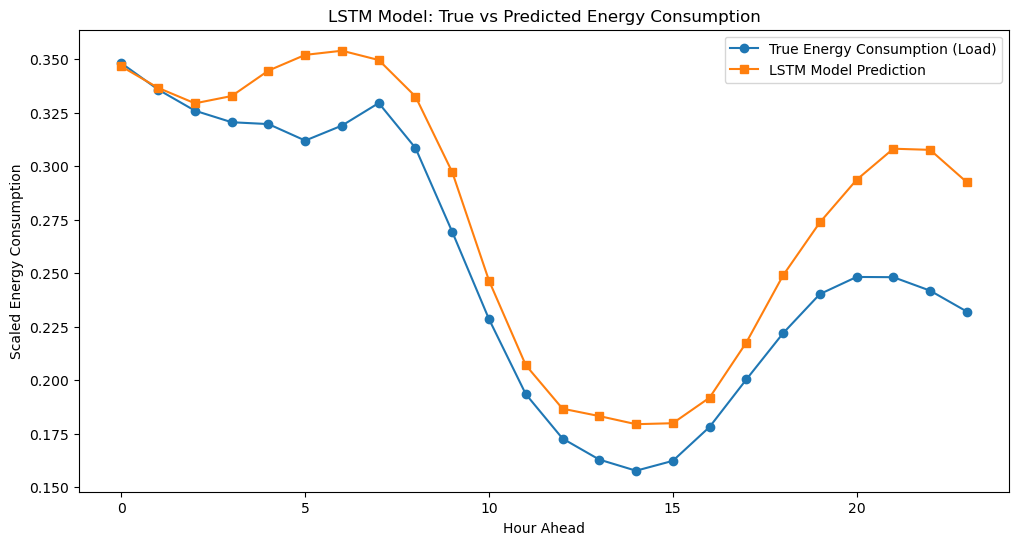

In [26]:
#MAE 

plt.figure(figsize=(12, 6))     
plt.title('LSTM Model: True vs Predicted Energy Consumption')
plt.plot(actual_load, label='True Energy Consumption (Load)', marker='o')
plt.plot(predicted_load_lstm_sample, label='LSTM Model Prediction', marker='s')
plt.xlabel('Hour Ahead')
plt.ylabel('Scaled Energy Consumption')
plt.legend()        

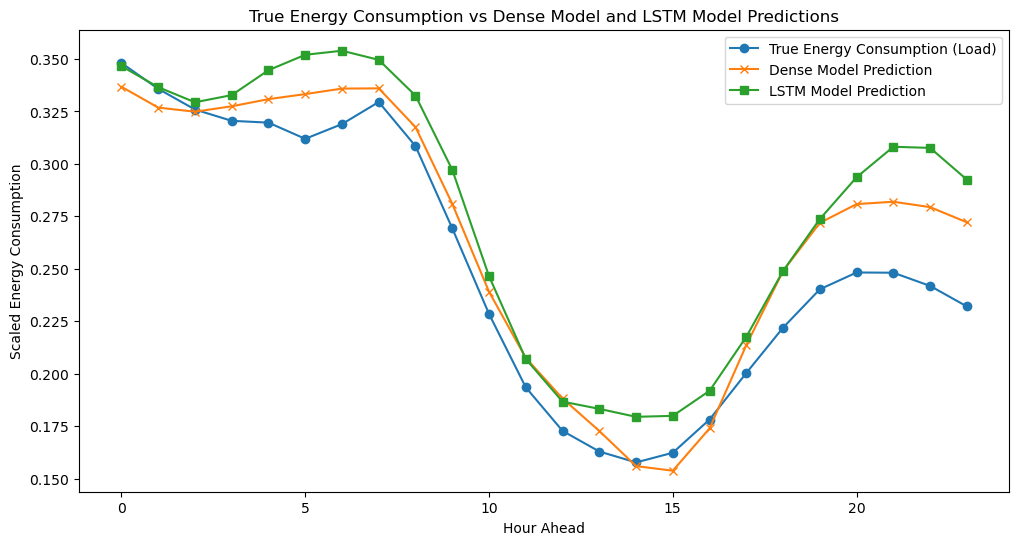

In [27]:
#comparing dense vs LSTM model visually
plt.figure(figsize=(12, 6))
plt.plot(y_test[sample], label='True Energy Consumption (Load)', marker='o')
plt.plot(predicted_load_dense_model.iloc[sample].values, label='Dense Model Prediction', marker='x')
plt.plot(predicted_load_lstm[sample], label='LSTM Model Prediction', marker='s')
plt.title('True Energy Consumption vs Dense Model and LSTM Model Predictions')
plt.xlabel('Hour Ahead')
plt.ylabel('Scaled Energy Consumption')
plt.legend()
plt.show()      